In [22]:
import pandas as pd
import numpy as np
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt
import re

In [23]:
df = pd.read_csv('Dataset Operations/dataset.csv')
df

,State FIPS,County FIPS,Postal,Name,Poverty Estimate All Ages,90% CI Lower Bound,90% CI Upper Bound,Poverty Percent All Ages,90% CI Lower Bound.1,90% CI Upper Bound.1,...,Cost Per Meal,Weighted Annual Food Budget Shortfall,LAUS Code,State FIPS Code,County FIPS Code,County Name/State Abbreviation,Labor Force,Employed,Unemployed,Unemployment Rate (%)
0,1,3.0,AL,Baldwin County,24728,20610,28846,13.4,11.2,15.6,...,2.64,10710730,CN0100300000000,1.0,3.0,"Baldwin County, AL",84269.0,75943.0,8326.0,9.9
1,1,15.0,AL,Calhoun County,23974,20930,27018,20.9,18.2,23.6,...,2.59,8925230,CN0101500000000,1.0,15.0,"Calhoun County, AL",52020.0,46200.0,5820.0,11.2
2,1,43.0,AL,Cullman County,14455,12204,16706,18.2,15.4,21.0,...,2.63,4925390,CN0104300000000,1.0,43.0,"Cullman County, AL",36291.0,32554.0,3737.0,10.3
3,1,49.0,AL,DeKalb County,14331,11742,16920,20.3,16.6,24.0,...,2.51,4843230,CN0104900000000,1.0,49.0,"DeKalb County, AL",31183.0,27322.0,3861.0,12.4
4,1,51.0,AL,Elmore County,10299,8444,12154,13.8,11.3,16.3,...,2.57,4941310,CN0105100000000,1.0,51.0,"Elmore County, AL",37049.0,33728.0,3321.0,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,55,133.0,WI,Waukesha County,21319,18172,24466,5.5,4.7,6.3,...,3.03,13195000,CN5513300000000,55.0,133.0,"Waukesha County, WI",221151.0,214657.0,6494.0,2.9
6431,55,139.0,WI,Winnebago County,19677,16997,22357,12.4,10.7,14.1,...,2.96,8680000,CN5513900000000,55.0,139.0,"Winnebago County, WI",92943.0,90166.0,2777.0,3.0
6432,55,141.0,WI,Wood County,9093,7724,10462,12.3,10.4,14.2,...,2.91,3515000,CN5514100000000,55.0,141.0,"Wood County, WI",38332.0,37022.0,1310.0,3.4
6433,56,21.0,WY,Laramie County,9008,7364,10652,9.9,8.1,11.7,...,3.14,5676000,CN5602100000000,56.0,21.0,"Laramie County, WY",48056.0,46216.0,1840.0,3.8


In [24]:
df.Year.describe()

count    6435.000000
mean       13.514996
std         2.291179
min        10.000000
25%        12.000000
50%        14.000000
75%        16.000000
max        17.000000
Name: Year, dtype: float64

In [25]:
df["entity"] = df["Postal"].astype(str) + " " + df["Name"].astype(str)
df.entity.value_counts()

entity
AL Baldwin County     8
OH Lorain County      8
OH Mahoning County    8
OH Marion County      8
OH Medina County      8
                     ..
IN Boone County       1
NC Franklin County    1
SC Kershaw County     1
TX Wise County        1
UT Tooele County      1
Name: count, Length: 816, dtype: int64

In [26]:
entity_effects_column = 'entity'
time_effects_column = 'Year'
TREATMENT_YEAR = 13
SNAP_TREATMENT_QUANTILE = 0.30 #counties above this SNAP percentile are "treated"

df['rel_time'] = df[time_effects_column] - TREATMENT_YEAR
event_dummies = pd.get_dummies(df['rel_time'], prefix='evt', drop_first=False)
event_dummies = event_dummies.drop(columns=['evt_-1'], errors='ignore')
df = pd.concat([df, event_dummies], axis=1)


snap_pre = (df[df['rel_time'] < 0].groupby('entity')['SNAP'].mean().rename('snap_pre_mean'))
snap_threshold = snap_pre.quantile(SNAP_TREATMENT_QUANTILE)
treated_entities = snap_pre[snap_pre >= snap_threshold].index
df['treated'] = df['entity'].isin(treated_entities).astype(int)
print(f"Treatment threshold (SNAP quantile {SNAP_TREATMENT_QUANTILE:.0%}): {snap_threshold:.2f}")
print(f"Treated counties: {treated_entities.nunique()} / {df['entity'].nunique()}")

evt_dummy_cols = [c for c in df.columns if c.startswith('evt_')]
for col in evt_dummy_cols:
    df[f'did_{col}'] = df['treated'] * df[col]
df = df.set_index([entity_effects_column, time_effects_column])
df = df.drop(index='DC District of Columbia', level=entity_effects_column)
obs_per_county = df.groupby(level=entity_effects_column).size()
balanced_counties = obs_per_county[obs_per_county > 6].index
df = df[df.index.get_level_values(entity_effects_column).isin(balanced_counties)]
df

Treatment threshold (SNAP quantile 30%): 10.18
Treated counties: 561 / 816


,,State FIPS,County FIPS,Postal,Name,Poverty Estimate All Ages,90% CI Lower Bound,90% CI Upper Bound,Poverty Percent All Ages,90% CI Lower Bound.1,90% CI Upper Bound.1,...,evt_3,evt_4,treated,did_evt_-3,did_evt_-2,did_evt_0,did_evt_1,did_evt_2,did_evt_3,did_evt_4
entity,Year,,,,,,,,,,,,,,,,,,,,,
AL Baldwin County,10,1,3.0,AL,Baldwin County,24728,20610,28846,13.4,11.2,15.6,...,False,False,0,0,0,0,0,0,0,0
AL Calhoun County,10,1,15.0,AL,Calhoun County,23974,20930,27018,20.9,18.2,23.6,...,False,False,1,1,0,0,0,0,0,0
AL Cullman County,10,1,43.0,AL,Cullman County,14455,12204,16706,18.2,15.4,21.0,...,False,False,1,1,0,0,0,0,0,0
AL DeKalb County,10,1,49.0,AL,DeKalb County,14331,11742,16920,20.3,16.6,24.0,...,False,False,1,1,0,0,0,0,0,0
AL Elmore County,10,1,51.0,AL,Elmore County,10299,8444,12154,13.8,11.3,16.3,...,False,False,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WI Waukesha County,17,55,133.0,WI,Waukesha County,21319,18172,24466,5.5,4.7,6.3,...,False,True,0,0,0,0,0,0,0,0
WI Winnebago County,17,55,139.0,WI,Winnebago County,19677,16997,22357,12.4,10.7,14.1,...,False,True,0,0,0,0,0,0,0,0
WI Wood County,17,55,141.0,WI,Wood County,9093,7724,10462,12.3,10.4,14.2,...,False,True,1,0,0,0,0,0,0,1


# Model Estimation

In [27]:
menu_of_regressands = {
       'Poverty Percent All Ages',
       'Poverty Percent Under Age 18',
       'Poverty Percent Ages 5-17', 'FI Rate',
       'Child FI Rate', '% FI Children Below 185 FPL',
       'Cost Per Meal', "Weighted Annual Food Budget Shortfall", "Num FI Persons"
}


In [46]:
interesting_cols = ["Labor Force", "Unemployment Rate (%)", "Weighted Annual Food Budget Shortfall", "Num FI Persons"]
df[interesting_cols].describe()

,Labor Force,Unemployment Rate (%),Weighted Annual Food Budget Shortfall,Num FI Persons
count,6.365000e+03,6365.000000,6.365000e+03,6.365000e+03
mean,1.644800e+05,6.795035,2.296356e+07,4.559932e+04
std,2.914040e+05,2.677364,4.365253e+07,8.547651e+04
min,2.013900e+04,2.000000,2.019080e+06,4.030000e+03
25%,4.654500e+04,4.900000,6.384000e+06,1.323000e+04
50%,7.636900e+04,6.300000,1.035100e+07,2.102000e+04
75%,1.663520e+05,8.300000,2.243900e+07,4.499000e+04
max,5.107316e+06,29.100000,8.159430e+08,1.749600e+06


In [29]:
def run_regression(regressand, snap_quantile=SNAP_TREATMENT_QUANTILE, log_left = False, controls = None):
    if regressand not in menu_of_regressands:
        raise ValueError(f"{regressand} not in menu_of_regressands")

    if snap_quantile != SNAP_TREATMENT_QUANTILE:
        snap_pre = (df[df.index.get_level_values('Year') < TREATMENT_YEAR].groupby(level='entity')['SNAP'].mean())
        threshold = snap_pre.quantile(snap_quantile)
        treated_mask = snap_pre >= threshold
        treated_series = treated_mask.reindex(df.index.get_level_values('entity')).values.astype(int)
        evt_dummy_cols = [c for c in df.columns if c.startswith('evt_')]
        did_cols_local = []
        for col in evt_dummy_cols:
            name = f'did_{col}_q{int(snap_quantile*100)}'
            df[name] = treated_series * df[col].values
            did_cols_local.append(name)
        did_cols = did_cols_local
    else:
        did_cols = [c for c in df.columns if c.startswith('did_evt_')]

    y = df[regressand]
    if log_left: y = np.log(y)
    control_cols = controls if controls is not None else []
    X = df[did_cols+control_cols]

    model = PanelOLS(dependent=y, exog=X, entity_effects=True, time_effects=True, drop_absorbed=True)
    result = model.fit(cov_type='clustered', cluster_entity=True)
    return result

In [30]:
def plot_event_study(result, regressand, log_left=False):
    params = result.params
    ci = result.conf_int()
    pattern = re.compile(r'did_evt_(-?\d+)$')
    times, coefs, lower, upper = [], [], [], []
    for k in params.index:
        m = pattern.search(k)
        if m:
            t = int(m.group(1))
            times.append(t)
            coefs.append(params[k])
            lower.append(ci.loc[k, 'lower'])
            upper.append(ci.loc[k, 'upper'])
    times += [-1]
    coefs += [0.0]
    lower += [0.0]
    upper += [0.0]
    order = sorted(range(len(times)), key=lambda i: times[i])
    times = [times[i] for i in order]
    coefs = [coefs[i] for i in order]
    lower = [lower[i] for i in order]
    upper = [upper[i] for i in order]

    _, ax = plt.subplots(figsize=(10, 5))
    ax.fill_between(times, lower, upper, alpha=0.2, color='steelblue', label='95% CI')
    ax.plot(times, coefs, marker='o', color='steelblue')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(-0.5, color='red', linewidth=1, linestyle=':', label='Lapse (2013)')
    ax.set_xlabel('Event Time (years relative to 2013 lapse)')
    ax.set_ylabel('DiD Coefficient (Treated vs Control)')
    ax.set_title(f'Event Study: SNAP Lapse Effect on {"log " if log_left else ""}{regressand}')
    ax.legend()

    if log_left:
        ax2 = ax.twinx()
        y_min, y_max = ax.get_ylim()
        ax2.set_ylim((np.exp(y_min) - 1) * 100, (np.exp(y_max) - 1) * 100)
        ax2.set_ylabel('Approximate % Change')
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    plt.show()

# Compute All

In [31]:
results = {}
success = {}
for regressand in menu_of_regressands:
    try:
        results[regressand] = run_regression(regressand, controls = ["Unemployment Rate (%)"])
        success[regressand] = True
        print(f"Ran {regressand}")
    except Exception as e:
        success[regressand] = False
        print(f"Failed {regressand}: {e}")

Ran % FI Children Below 185 FPL
Ran Num FI Persons
Failed Poverty Percent All Ages: float division by zero
Failed Poverty Percent Ages 5-17: float division by zero
Failed Poverty Percent Under Age 18: float division by zero
Ran FI Rate
Ran Child FI Rate
Ran Cost Per Meal
Ran Weighted Annual Food Budget Shortfall


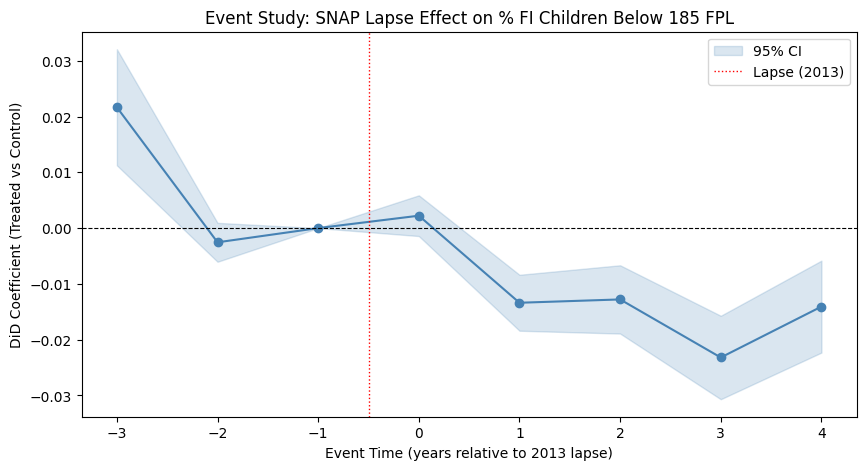

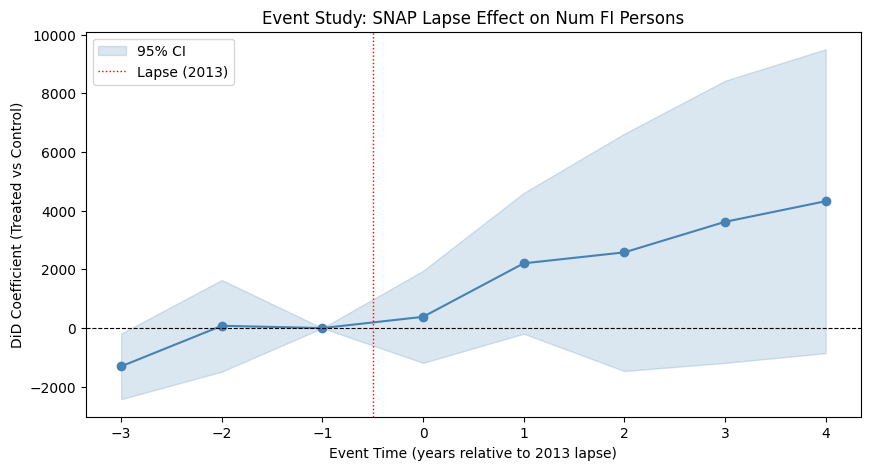

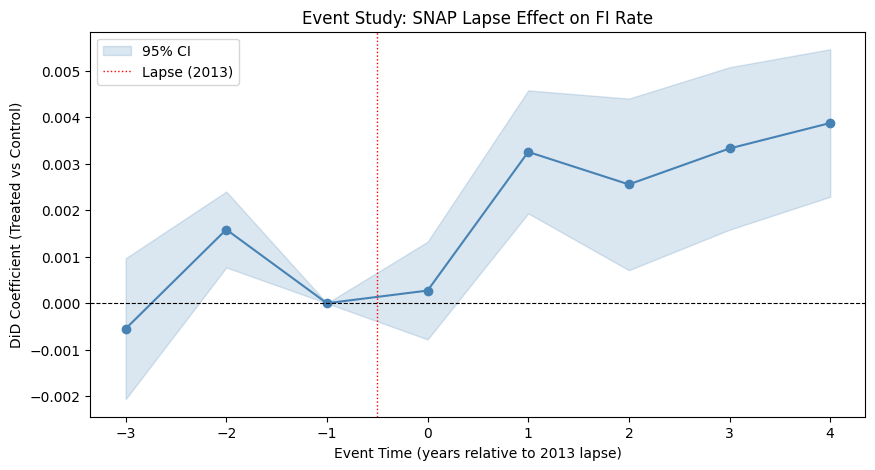

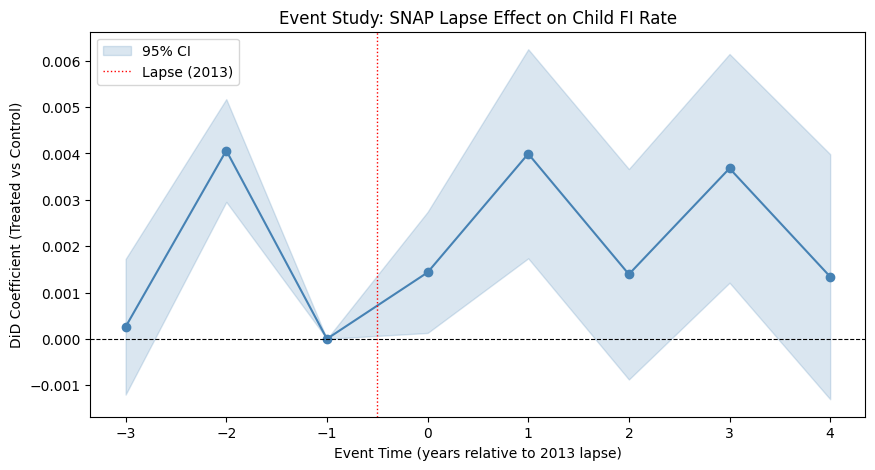

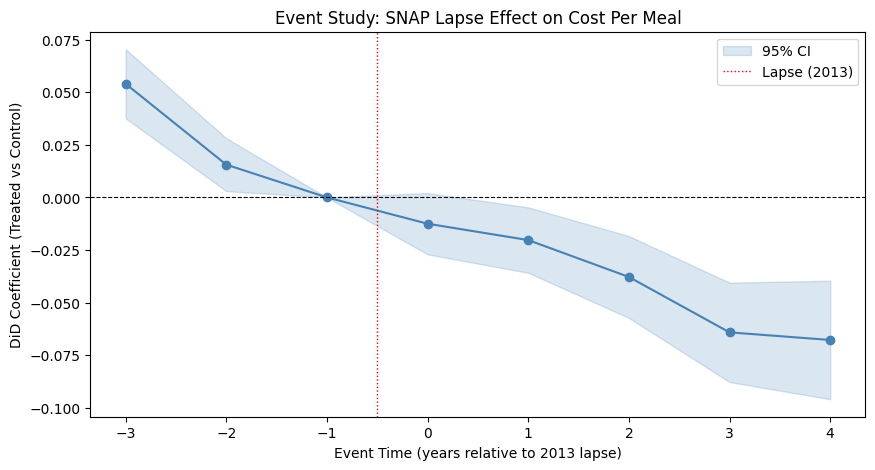

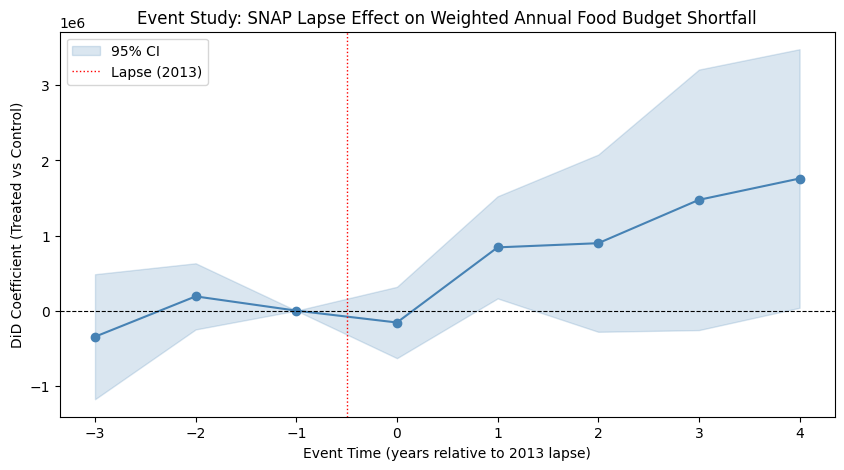

In [32]:
for regressand in menu_of_regressands:
        if success[regressand]:
            plot_event_study(results[regressand], regressand)

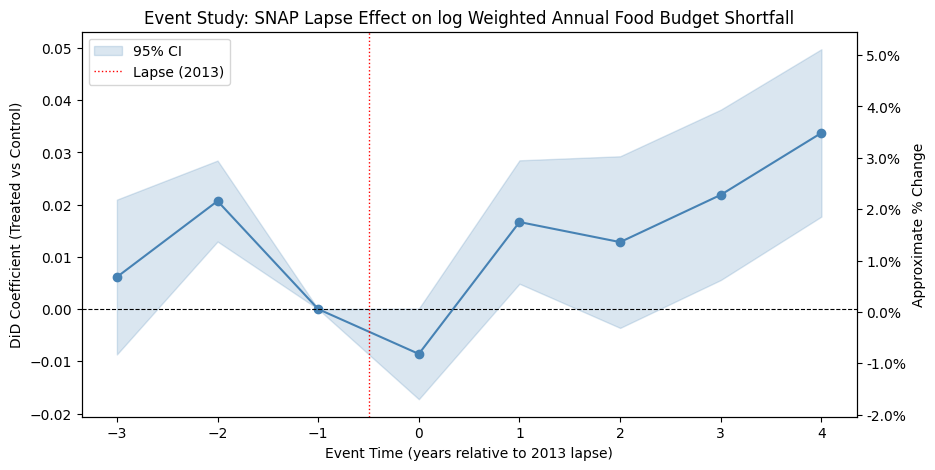

In [33]:
plot_event_study(run_regression('Weighted Annual Food Budget Shortfall', log_left=True, controls=["Unemployment Rate (%)"]), 'Weighted Annual Food Budget Shortfall', log_left=True)

In [34]:
run_regression('Weighted Annual Food Budget Shortfall', log_left=False, controls=["Unemployment Rate (%)"])

Dep. Variable:,Weighted Annual Food Budget Shortfall,R-squared:,0.0264
Estimator:,PanelOLS,R-squared (Between):,0.0939
No. Observations:,6365,R-squared (Within):,-0.1113
Date:,"Tue, Jun 09 2026",R-squared (Overall):,0.0925
Time:,03:24:54,Log-likelihood,-1.054e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,18.844
Entities:,796,P-value,0.0000
Avg Obs:,7.9962,Distribution:,"F(8,5554)"
Min Obs:,7.0000,,
Max Obs:,8.0000,F-statistic (robust):,11.100


# Pre trends violation tests

In [35]:
df_pretrends = pd.read_csv('Dataset Operations/dataset.csv')
df_pretrends["entity"] = df_pretrends["Postal"].astype(str) + " " + df_pretrends["Name"].astype(str)
 
df_pretrends['rel_time'] = df_pretrends['Year'] - TREATMENT_YEAR
event_dummies = pd.get_dummies(df_pretrends['rel_time'], prefix='evt', drop_first=False)
event_dummies = event_dummies.drop(columns=['evt_-1'], errors='ignore')
df_pretrends = pd.concat([df_pretrends, event_dummies], axis=1)
 
snap_pre = df_pretrends[df_pretrends['rel_time'] < 0].groupby('entity')['SNAP'].mean().rename('snap_pre_mean')
snap_threshold = snap_pre.quantile(SNAP_TREATMENT_QUANTILE)
treated_entities = snap_pre[snap_pre >= snap_threshold].index
df_pretrends['treated'] = df_pretrends['entity'].isin(treated_entities).astype(int)
 
evt_dummy_cols = [c for c in df_pretrends.columns if c.startswith('evt_')]
for col in evt_dummy_cols:
    df_pretrends[f'did_{col}'] = df_pretrends['treated'] * df_pretrends[col]
 
df_pretrends = df_pretrends.set_index(['entity', 'Year'])
df_pretrends = df_pretrends.drop(index='DC District of Columbia', level='entity', errors='ignore')
obs_per_county = df_pretrends.groupby(level='entity').size()
balanced_counties = obs_per_county[obs_per_county > 6].index
df_pretrends = df_pretrends[df_pretrends.index.get_level_values('entity').isin(balanced_counties)]
 

df_pretrends_pre = df_pretrends[df_pretrends.index.get_level_values('Year') < TREATMENT_YEAR]
pre_did_cols = [c for c in df_pretrends_pre.columns if re.match(r'did_evt_-\d+', c)]

 
for regressand in menu_of_regressands:
    if not success[regressand]: continue
    y = df_pretrends_pre[regressand]
    X = df_pretrends_pre[pre_did_cols]
    model = PanelOLS(dependent=y, exog=X, entity_effects=True, time_effects=True, drop_absorbed=True)
    result = model.fit(cov_type='clustered', cluster_entity=True)
    print(f"\n{'='*60}")
    print(f"{regressand}")
    print('='*60)
    print(result.summary.tables[1])


% FI Children Below 185 FPL
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
did_evt_-3     0.0202     0.0061     3.2868     0.0010      0.0081      0.0322
did_evt_-2    -0.0036     0.0020    -1.7746     0.0762     -0.0076      0.0004

Num FI Persons
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
did_evt_-3    -627.43     568.72    -1.1032     0.2701     -1742.9      488.09
did_evt_-2     523.74     810.84     0.6459     0.5184     -1066.7      2114.2

FI Rate
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper C

# FI vs Shortfall

In [36]:
run_regression('Weighted Annual Food Budget Shortfall', log_left=False, controls=["Unemployment Rate (%)", "Num FI Persons"])

Dep. Variable:,Weighted Annual Food Budget Shortfall,R-squared:,0.4177
Estimator:,PanelOLS,R-squared (Between):,0.7332
No. Observations:,6365,R-squared (Within):,0.3218
Date:,"Tue, Jun 09 2026",R-squared (Overall):,0.7304
Time:,03:24:55,Log-likelihood,-1.038e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,442.67
Entities:,796,P-value,0.0000
Avg Obs:,7.9962,Distribution:,"F(9,5553)"
Min Obs:,7.0000,,
Max Obs:,8.0000,F-statistic (robust):,47.767


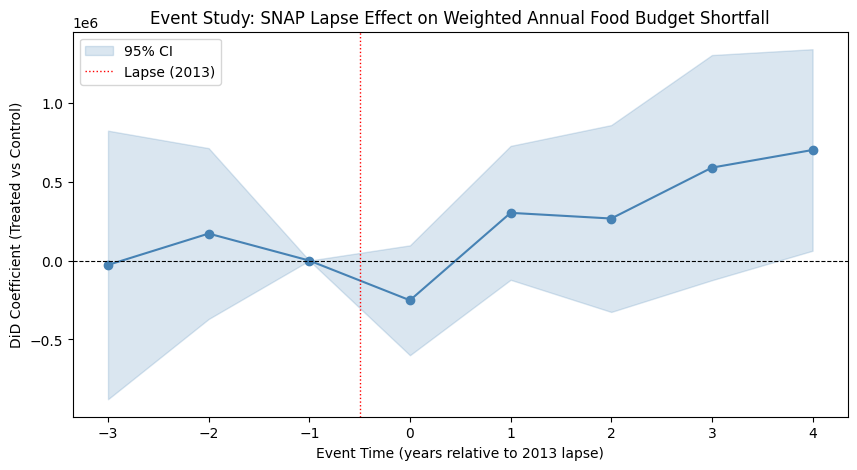

In [37]:
plot_event_study(run_regression('Weighted Annual Food Budget Shortfall', log_left=False, controls=["Unemployment Rate (%)", "Num FI Persons"]), "Weighted Annual Food Budget Shortfall", log_left=False)

In [38]:
y = df_pretrends_pre['Weighted Annual Food Budget Shortfall']
X = df_pretrends_pre[pre_did_cols + ["Unemployment Rate (%)", "Num FI Persons"]]
model = PanelOLS(dependent=y, exog=X, entity_effects=True, time_effects=True, drop_absorbed=True)
result = model.fit(cov_type='clustered', cluster_entity=True)
print(result.summary.tables[1])

                                   Parameter Estimates                                   
                       Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------
did_evt_-3             2.293e+04  4.492e+05     0.0510     0.9593  -8.581e+05    9.04e+05
did_evt_-2             1.381e+05  3.712e+05     0.3720     0.7099  -5.899e+05   8.661e+05
Unemployment Rate (%)  8.115e+04  1.721e+05     0.4716     0.6373  -2.564e+05   4.187e+05
Num FI Persons            311.07     80.828     3.8486     0.0001      152.53      469.61


### Include labor force

In [39]:
run_regression('Weighted Annual Food Budget Shortfall', log_left=False, controls=["Num FI Persons", "Labor Force"])

Dep. Variable:,Weighted Annual Food Budget Shortfall,R-squared:,0.5633
Estimator:,PanelOLS,R-squared (Between):,0.0804
No. Observations:,6365,R-squared (Within):,0.5253
Date:,"Tue, Jun 09 2026",R-squared (Overall):,0.0834
Time:,03:24:55,Log-likelihood,-1.029e+05
Cov. Estimator:,Clustered,,
,,F-statistic:,795.85
Entities:,796,P-value,0.0000
Avg Obs:,7.9962,Distribution:,"F(9,5553)"
Min Obs:,7.0000,,
Max Obs:,8.0000,F-statistic (robust):,63.005


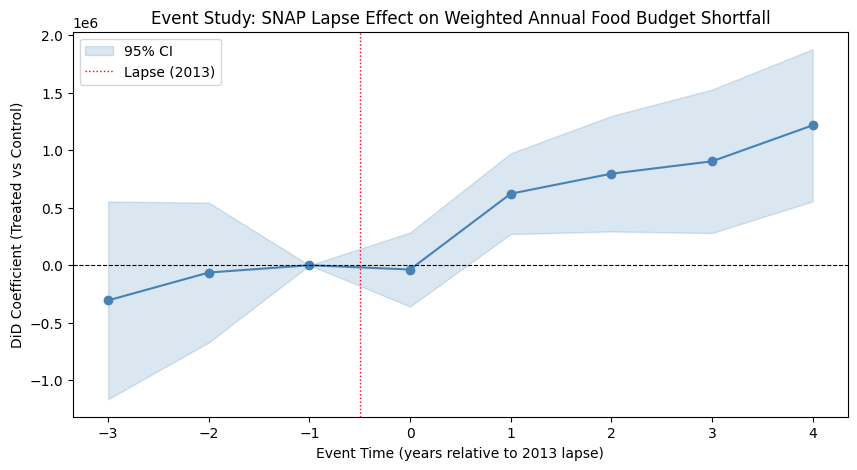

In [40]:
plot_event_study(run_regression('Weighted Annual Food Budget Shortfall', log_left=False, controls=["Labor Force", "Num FI Persons"]), "Weighted Annual Food Budget Shortfall", log_left=False)

In [41]:
y = df_pretrends_pre['Weighted Annual Food Budget Shortfall']
X = df_pretrends_pre[pre_did_cols + ["Labor Force", "Num FI Persons"]]
model = PanelOLS(dependent=y, exog=X, entity_effects=True, time_effects=True, drop_absorbed=True)
result = model.fit(cov_type='clustered', cluster_entity=True)
print(result.summary.tables[1])

                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
did_evt_-3     -7.093e+05  5.668e+05    -1.2514     0.2110  -1.821e+06   4.025e+05
did_evt_-2     -2.738e+05  3.781e+05    -0.7240     0.4691  -1.015e+06   4.679e+05
Labor Force        412.65     93.490     4.4139     0.0000      229.27      596.03
Num FI Persons     258.93     53.384     4.8503     0.0000      154.22      363.64


# Robustness

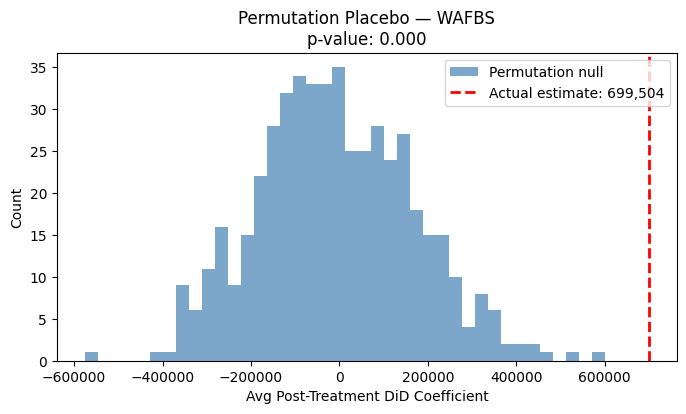

In [42]:
import matplotlib.pyplot as plt

n_permutations = 500
null_post_coefs = []

for i in range(n_permutations):
    entities = df.index.get_level_values('entity').unique()
    n_treated = df[df.index.get_level_values('Year') == df.index.get_level_values('Year').min()]['treated'].sum()
    fake_treated = np.random.choice(entities, size=int(len(entities) * SNAP_TREATMENT_QUANTILE), replace=False)
    df_perm = df.copy()
    df_perm['perm_treated'] = df_perm.index.get_level_values('entity').isin(fake_treated).astype(int)
    evt_dummy_cols = [c for c in df_perm.columns if c.startswith('evt_')]
    perm_did_cols = []
    for col in evt_dummy_cols:
        colname = f'perm_did_{col}'
        df_perm[colname] = df_perm['perm_treated'] * df_perm[col]
        perm_did_cols.append(colname)
    try:
        y = df_perm['Weighted Annual Food Budget Shortfall']
        X = df_perm[perm_did_cols + ["Labor Force", "Num FI Persons"]]
        model = PanelOLS(dependent=y, exog=X, entity_effects=True, time_effects=True, drop_absorbed=True)
        result = model.fit(cov_type='clustered', cluster_entity=True)
        pattern = re.compile(r'perm_did_evt_(\d+)$')
        post_coefs = [result.params[k] for k in result.params.index if pattern.search(k)]
        null_post_coefs.append(np.mean(post_coefs))
    except:
        continue

actual_result = run_regression('Weighted Annual Food Budget Shortfall', controls=["Labor Force", "Num FI Persons"])
pattern = re.compile(r'did_evt_(\d+)$')
actual_post = np.mean([actual_result.params[k] for k in actual_result.params.index if pattern.search(k)])
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(null_post_coefs, bins=40, color='steelblue', alpha=0.7, label='Permutation null')
ax.axvline(actual_post, color='red', linewidth=2, linestyle='--', label=f'Actual estimate: {actual_post:,.0f}')
p_value = np.mean(np.abs(null_post_coefs) >= np.abs(actual_post))
ax.set_title(f'Permutation Placebo — WAFBS\np-value: {p_value:.3f}')
ax.set_xlabel('Avg Post-Treatment DiD Coefficient')
ax.set_ylabel('Count')
ax.legend()
plt.show()

C:\Users\Ata\AppData\Local\Temp\ipykernel_67720\1811027561.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = treated_series * df[col].values
C:\Users\Ata\AppData\Local\Temp\ipykernel_67720\1811027561.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = treated_series * df[col].values
C:\Users\Ata\AppData\Local\Temp\ipykernel_67720\1811027561.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider jo

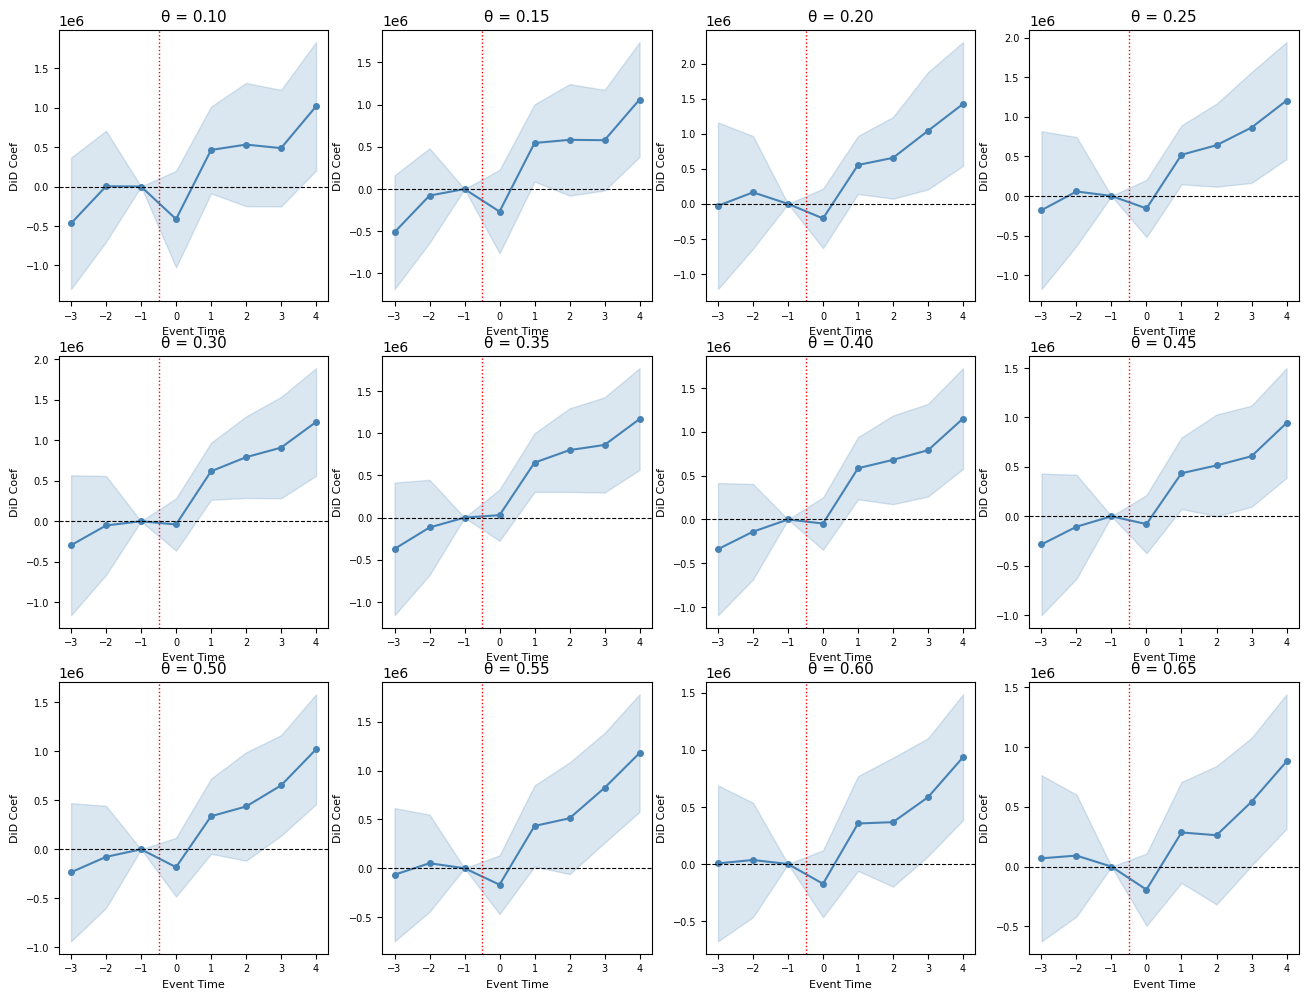

In [43]:
thresholds = np.arange(0.10, 0.66, 0.05)
ncols = 4
nrows = int(np.ceil(len(thresholds) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4), sharey=False)
axes = axes.flatten()
for i, q in enumerate(thresholds):
    ax = axes[i]
    result = run_regression('Weighted Annual Food Budget Shortfall', snap_quantile=q, log_left=False, controls=["Labor Force", "Num FI Persons"])
    params = result.params
    ci = result.conf_int()
    pattern = re.compile(r'did_evt_(-?\d+)')
    times, coefs, lower, upper = [], [], [], []
    for k in params.index:
        m = pattern.search(k)
        if m:
            t = int(m.group(1))
            times.append(t)
            coefs.append(params[k])
            lower.append(ci.loc[k, 'lower'])
            upper.append(ci.loc[k, 'upper'])
    times += [-1]; coefs += [0.0]; lower += [0.0]; upper += [0.0]
    order = sorted(range(len(times)), key=lambda i: times[i])
    times = [times[i] for i in order]
    coefs = [coefs[i] for i in order]
    lower = [lower[i] for i in order]
    upper = [upper[i] for i in order]

    ax.fill_between(times, lower, upper, alpha=0.2, color='steelblue')
    ax.plot(times, coefs, marker='o', markersize=4, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.axvline(-0.5, color='red', linewidth=1, linestyle=':')
    ax.set_title(f'θ = {q:.2f}', fontsize=11)
    ax.set_xlabel('Event Time', fontsize=8)
    ax.set_ylabel('DiD Coef', fontsize=8)
    ax.tick_params(labelsize=7)

plt.show()